In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
def compute_t_stat(values, errors):
    t = +values
    mask = errors != 0
    t[mask] /= errors[mask]
    return t

In [3]:
t_19 = 3.579 # threshold of one-tailed t statistics for 19 dof and p=0.001

# 1) minzero = True (Transfer entropy cannot be negative)
### Rossler, identical

In [6]:
epsilons = np.linspace(0.,0.25,30)
nseeds = 20
k = 3
minzero = True

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/rossler_id/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/rossler_id/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [65]:
# false positive detections in direction Y -> X
mask = epsilons < 0.18

fpd_Y_to_X = (compute_t_stat(TE_mean_Y_to_X[mask], TE_err_Y_to_X[mask]) > t_19).sum()
fpd_emb_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb[mask], TE_err_Y_to_X_emb[mask]) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_Y_to_X}\t{100*fpd_Y_to_X/len(epsilons[mask]):.2f}")
print(f"IGemb:\t{fpd_emb_Y_to_X}\t{100*fpd_emb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"Number of espilons considered: {len(epsilons[mask])}")

Number and % of false positive detections:
IG:	21	100.00
IGemb:	21	100.00
Number of espilons considered: 21


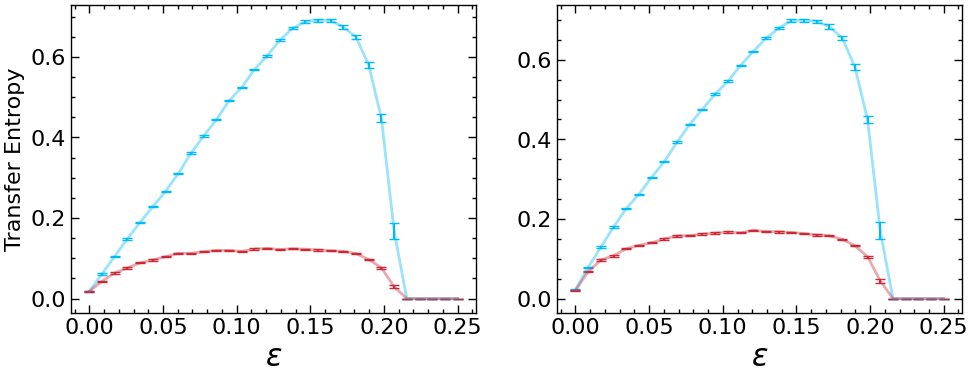

In [66]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig(f"./figures/rossler_id_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Rossler, different

In [7]:
epsilons = np.linspace(0.,0.25,30)
nseeds = 20

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/rossler_diff/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/rossler_diff/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [ ]:
# false positive detections in direction Y -> X
mask = epsilons < 0.18

fpd_Y_to_X = (compute_t_stat(TE_mean_Y_to_X[mask], TE_err_Y_to_X[mask]) > t_19).sum()
fpd_emb_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb[mask], TE_err_Y_to_X_emb[mask]) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_Y_to_X}\t{100*fpd_Y_to_X/len(epsilons[mask]):.2f}")
print(f"IGemb:\t{fpd_emb_Y_to_X}\t{100*fpd_emb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"Number of espilons considered: {len(epsilons[mask])}")

Number and % of false positive detections:
IG:	21	100.00
IGemb:	21	100.00
Number of espilons considered: 21


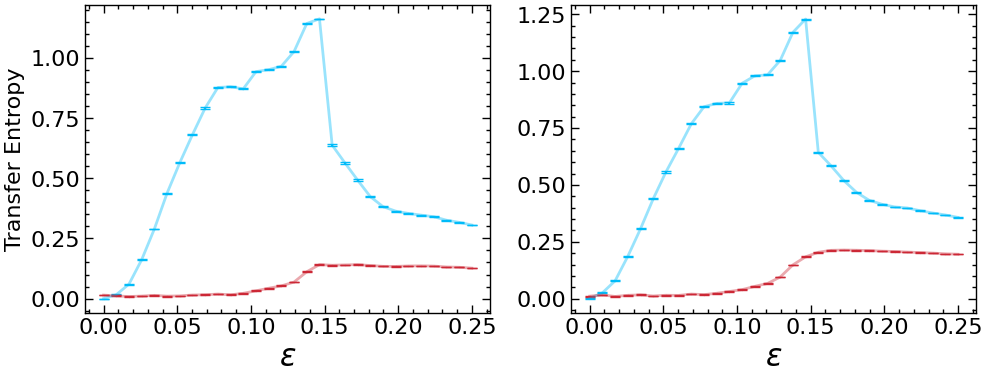

In [69]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig(f"./figures/rossler_diff_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

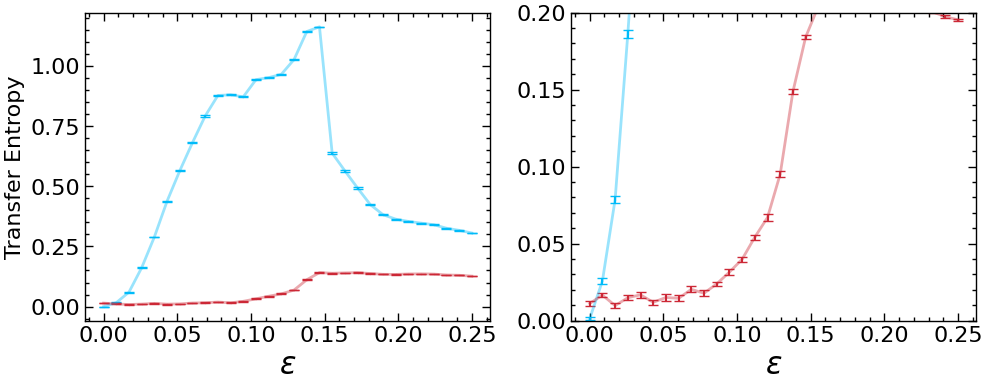

In [11]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)
ax[1].set(ylim=[0,0.20])

#plt.savefig(f"./figures/rossler_diff_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz

In [70]:
epsilons = np.linspace(0.,0.3,31)
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/lorenz/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/lorenz/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

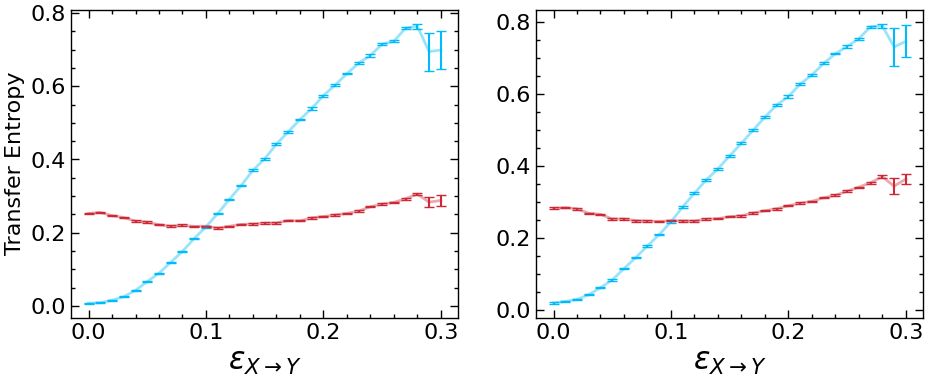

In [71]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)

plt.savefig(f"./figures/lorenz_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz 96

In [72]:
epsilons = np.linspace(0.,1.5,31)
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/lorenz96/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/lorenz96/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [73]:
# false positive detections in direction Y -> X
fpd_Y_to_X = (compute_t_stat(TE_mean_Y_to_X, TE_err_Y_to_X) > t_19).sum()
fpd_emb_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_Y_to_X}\t{100*fpd_Y_to_X/len(epsilons):.2f}")
print(f"IGemb:\t{fpd_emb_Y_to_X}\t{100*fpd_emb_Y_to_X/len(epsilons):.2f}")
print(f"Number of espilons considered: {len(epsilons)}")

Number and % of false positive detections:
IG:	31	100.00
IGemb:	31	100.00
Number of espilons considered: 31


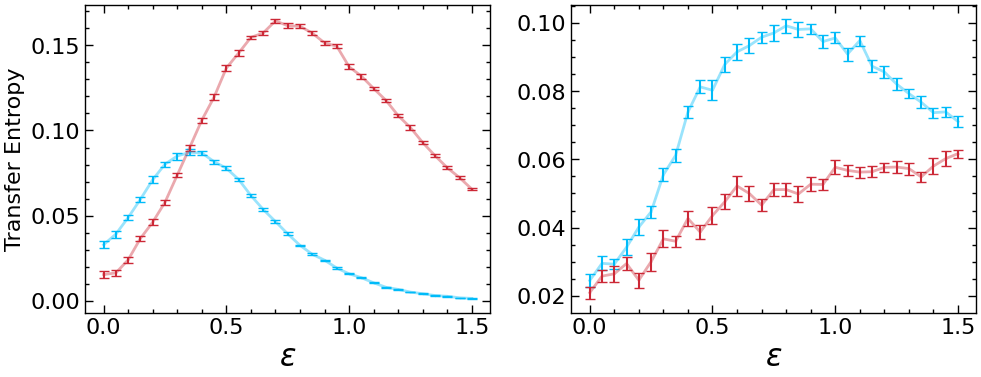

In [74]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig(f"./figures/lorenz96_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

# 2) minzero = False (Transfer entropy can be negative)
### Rossler, identical

In [14]:
epsilons = np.linspace(0.,0.25,30)
nseeds = 20
k = 3
minzero = False

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/rossler_id/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/rossler_id/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [76]:
# false positive detections in direction Y -> X
mask = epsilons < 0.18

fpd_Y_to_X = (compute_t_stat(TE_mean_Y_to_X[mask], TE_err_Y_to_X[mask]) > t_19).sum()
fpd_emb_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb[mask], TE_err_Y_to_X_emb[mask]) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_Y_to_X}\t{100*fpd_Y_to_X/len(epsilons[mask]):.2f}")
print(f"IGemb:\t{fpd_emb_Y_to_X}\t{100*fpd_emb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"Number of espilons considered: {len(epsilons[mask])}")

Number and % of false positive detections:
IG:	21	100.00
IGemb:	21	100.00
Number of espilons considered: 21


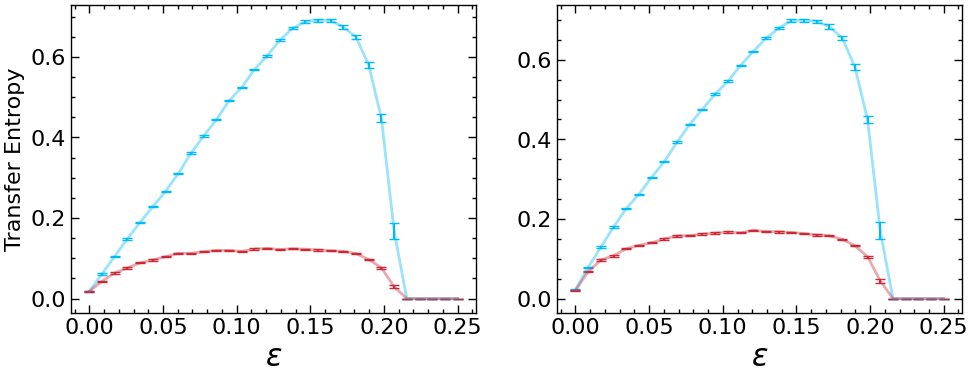

In [77]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig(f"./figures/rossler_id_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Rossler, different

In [15]:
epsilons = np.linspace(0.,0.25,30)
nseeds = 20

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/rossler_diff/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/rossler_diff/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [20]:
# false positive detections in direction Y -> X
mask = epsilons < 0.18

t_19 = 7

fpd_Y_to_X = (compute_t_stat(TE_mean_Y_to_X[mask], TE_err_Y_to_X[mask]) > t_19).sum()
fpd_emb_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb[mask], TE_err_Y_to_X_emb[mask]) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_Y_to_X}\t{100*fpd_Y_to_X/len(epsilons[mask]):.2f}")
print(f"IGemb:\t{fpd_emb_Y_to_X}\t{100*fpd_emb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"Number of espilons considered: {len(epsilons[mask])}")

Number and % of false positive detections:
IG:	15	71.43
IGemb:	17	80.95
Number of espilons considered: 21


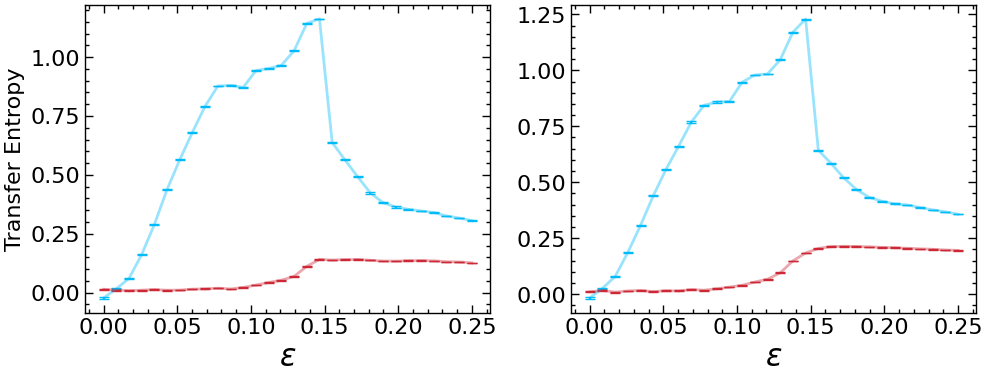

In [80]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig(f"./figures/rossler_diff_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

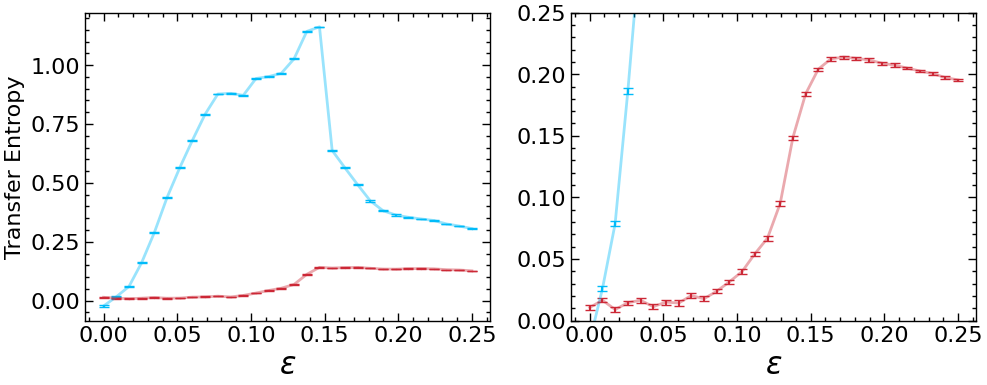

In [22]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)
ax[1].set(ylim=[0,0.25])

#plt.savefig(f"./figures/rossler_diff_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz

In [81]:
epsilons = np.linspace(0.,0.3,31)
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/lorenz/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/lorenz/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

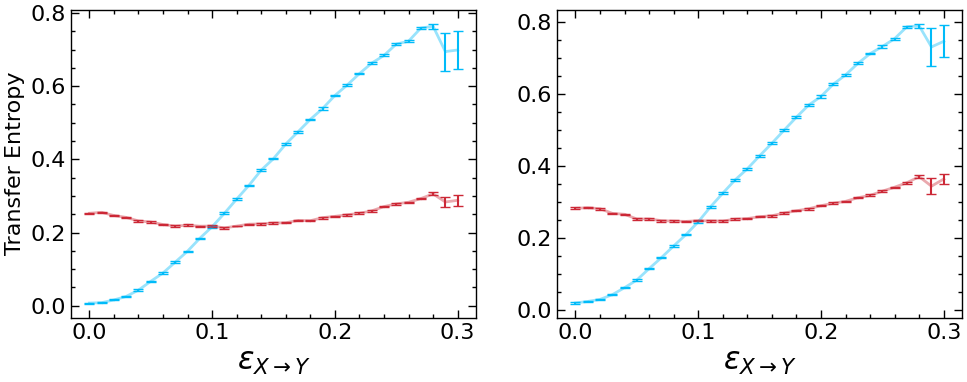

In [82]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)

plt.savefig(f"./figures/lorenz_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz 96

In [86]:
epsilons = np.linspace(0.,1.5,31)
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
transfer_entropies_X_to_Y = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y[seed], transfer_entropies_Y_to_X[seed] = pickle.load(open(f"./allcoords/pickles/lorenz96/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y = transfer_entropies_X_to_Y.mean(axis=0)
TE_err_X_to_Y = transfer_entropies_X_to_Y.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y.shape[0])
TE_mean_Y_to_X = transfer_entropies_Y_to_X.mean(axis=0)
TE_err_Y_to_X = transfer_entropies_Y_to_X.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X.shape[0])

# IG, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(open(f"./embeddings/pickles/lorenz96/seed{seed}_k{k}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [87]:
# false positive detections in direction Y -> X
fpd_Y_to_X = (compute_t_stat(TE_mean_Y_to_X, TE_err_Y_to_X) > t_19).sum()
fpd_emb_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_Y_to_X}\t{100*fpd_Y_to_X/len(epsilons):.2f}")
print(f"IGemb:\t{fpd_emb_Y_to_X}\t{100*fpd_emb_Y_to_X/len(epsilons):.2f}")
print(f"Number of espilons considered: {len(epsilons)}")

Number and % of false positive detections:
IG:	31	100.00
IGemb:	31	100.00
Number of espilons considered: 31


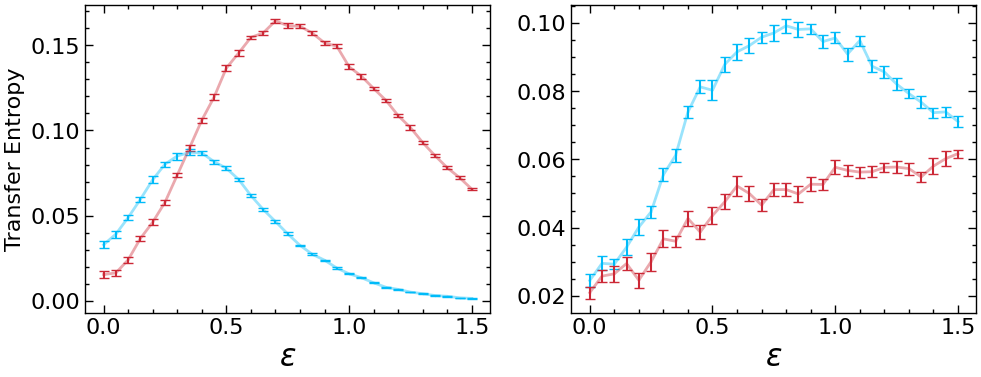

In [88]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(11.5,4))

ax[0].errorbar(epsilons, TE_mean_X_to_Y, TE_err_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, TE_mean_Y_to_X, TE_err_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, TE_mean_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, TE_mean_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Transfer Entropy")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Transfer Entropy")
#ax[1].axes.xaxis.set_ticklabels([])
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig(f"./figures/lorenz96_k{k}_minzero{minzero}.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()